# Price Prediction - Neural Network

Let's start by importing necessary packages.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

Now read in the dataframe and prepare it for use with `XGBoost`.

In [ ]:
df = pd.read_parquet("../all_car_details_cleaned.parquet")

## Preparing Data for XGBoost

Let's first drop useless columns.

In [ ]:
columns_to_drop = [
    "url",
    "num_images",
    "general_inspection",
    "emission_class",
    "comfort_and_convenience",
    "safety_and_security",
    "entertainment_and_media",
    "extras",
    "paint",
]


df.drop(columns=columns_to_drop, errors="ignore", inplace=True)

Now since XGBoost does not need any scaling, imputing of missing values or turning to tensors, let's start by splitting to ensure no data leakage happens and then split the dataset before applying grouping and OHE.

In [ ]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# We'll do this after grouping for high cardinality features
high_card_features = ['make', 'car_title'] # Features to apply grouping
# Other categorical features that don't need grouping but need OHE
# Exclude high_card_features as they will be handled, and ensure no numeric features are accidentally included
other_categorical_features = [col for col in X_train.select_dtypes(include=['object', 'category']).columns if col not in high_card_features]
numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()

print(f"High cardinality features to group: {high_card_features}")
print(f"Other categorical features for OHE: {other_categorical_features}")
print(f"Numerical features: {numerical_features}")

High cardinality features to group: ['make', 'car_title']
Other categorical features for OHE: ['seller', 'location', 'body_type', 'used_type', 'drivetrain', 'seats', 'doors', 'full_service_history', 'gearbox', 'gears', 'cylinders', 'fuel_type', 'exterior_colour', 'upholstery_colour', 'upholstery']
Numerical features: ['mileage', 'previous_owner', 'power', 'engine_size', 'empty_weight', 'fuel_consumption', 'co2_emissions', 'age_months']


In [ ]:
# --- 5. Grouping High Cardinality Features (Learned from X_train, Applied to X_train & X_test) ---
def get_rare_categories(series, threshold_percentage):
    value_counts_normalized = series.value_counts(normalize=True)
    return value_counts_normalized[value_counts_normalized < threshold_percentage].index

make_threshold_percentage = 0.0001
title_threshold_percentage = 0.00005

# Create copies to avoid SettingWithCopyWarning
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

for feature, threshold in zip(['make', 'car_title'], [make_threshold_percentage, title_threshold_percentage]):
    if feature in X_train_processed.columns:
        print(f"\nProcessing feature: {feature}")
        print(f"Unique values in X_train before grouping: {X_train_processed[feature].nunique()}")
        
        # Learn rare categories from X_train
        rare_categories_train = get_rare_categories(X_train_processed[feature], threshold)
        
        # Apply to X_train
        X_train_processed[feature] = X_train_processed[feature].apply(lambda x: f'Other_{feature}' if x in rare_categories_train else x)
        print(f"Unique values in X_train after grouping: {X_train_processed[feature].nunique()}")
        
        # Apply to X_test (using rare categories learned from X_train)
        if feature in X_test_processed.columns:
            X_test_processed[feature] = X_test_processed[feature].apply(lambda x: f'Other_{feature}' if x in rare_categories_train else x)
            # Handle new categories in X_test not seen in X_train's common categories
            # by mapping them to 'Other_feature' as well
            common_categories_train = X_train_processed[feature].unique()
            X_test_processed[feature] = X_test_processed[feature].apply(lambda x: f'Other_{feature}' if x not in common_categories_train else x)
            print(f"Unique values in X_test after grouping: {X_test_processed[feature].nunique()}")
    else:
        print(f"Feature {feature} not found in X_train.")

# Update the list of categorical features for OHE to include the now-grouped high-cardinality ones
all_categorical_features_for_ohe = high_card_features + other_categorical_features

total_ohe_cols_estimate = 0
print("\n--- Estimating OHE columns ---")
for col in all_categorical_features_for_ohe:
    if col in X_train_processed.columns:
        unique_vals = X_train_processed[col].nunique()
        print(f"Feature '{col}': {unique_vals} unique values (after grouping/filling NaNs)")
        total_ohe_cols_estimate += unique_vals
    else:
        print(f"Feature '{col}' not found in X_train_processed for OHE estimation.")
print(f"Estimated total columns from OHE (if drop=None): {total_ohe_cols_estimate}")
print(f"Numerical features to be passed through: {len(numerical_features)}")
print(f"Grand total estimated features: {total_ohe_cols_estimate + len(numerical_features)}")


Processing feature: make
Unique values in X_train before grouping: 220
Unique values in X_train after grouping: 109
Unique values in X_test after grouping: 109

Processing feature: car_title
Unique values in X_train before grouping: 2756
Unique values in X_train after grouping: 1362
Unique values in X_test after grouping: 1360

--- Estimating OHE columns ---
Feature 'make': 109 unique values (after grouping/filling NaNs)
Feature 'car_title': 1362 unique values (after grouping/filling NaNs)
Feature 'seller': 3 unique values (after grouping/filling NaNs)
Feature 'location': 9 unique values (after grouping/filling NaNs)
Feature 'body_type': 28 unique values (after grouping/filling NaNs)
Feature 'used_type': 6 unique values (after grouping/filling NaNs)
Feature 'drivetrain': 3 unique values (after grouping/filling NaNs)
Feature 'seats': 28 unique values (after grouping/filling NaNs)
Feature 'doors': 10 unique values (after grouping/filling NaNs)
Feature 'full_service_history': 2 unique va

In [ ]:
# --- 6. Preprocessing with ColumnTransformer and Pipeline ---
# XGBoost handles NaNs in numerical features. For categorical, OHE needs a strategy.
# We can impute categorical NaNs with a placeholder like 'Missing' before OHE.

# Create a list of transformers
# For OHE, handle_unknown='ignore' will assign all zeros to categories encountered in test but not in train.
# If NaNs are present in categorical columns, OneHotEncoder will raise an error by default.
# We should fill them or use a specific strategy.
# Let's fill NaNs in categorical columns before OHE for simplicity here.
print("Filling NaNs in categorical features with 'Missing_Cat_Value'...")
for col in all_categorical_features_for_ohe:
    if col in X_train_processed.columns:
        X_train_processed[col] = X_train_processed[col].fillna('Missing_Cat_Value')
    if col in X_test_processed.columns:
        X_test_processed[col] = X_test_processed[col].fillna('Missing_Cat_Value')
        
print("NaNs filled in categorical features.")


# Define the ColumnTransformer
# Numerical features will pass through as XGBoost handles their NaNs and doesn't require scaling.
# If you had numerical features needing imputation/scaling, you'd add a ('num', SimpleImputer/StandardScaler, numerical_features)
preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True, drop=None), all_categorical_features_for_ohe)
    ],
    remainder='passthrough'  # Keep numerical columns not specified in transformers
)
print("Preprocessor created with OneHotEncoder for categorical features and passthrough for numerical features.")

# Fit the preprocessor on X_train_processed and transform both
X_train_final = preprocessor.fit_transform(X_train_processed)
print("Preprocessor fitted and transformed X_train_processed.")
print(f"Type of X_train_final: {type(X_train_final)}") # Should be <class 'scipy.sparse._csr.csr_matrix'> or similar
print(f"Shape of sparse X_train_final: {X_train_final.shape}")

X_test_final = preprocessor.transform(X_test_processed)
print("X_test_processed transformed using the fitted preprocessor.")
print(f"Shape of sparse X_test_final: {X_test_final.shape}")

# Get feature names after OHE for DMatrix or if you want to convert back to DataFrame
# This can be a bit tricky with ColumnTransformer and passthrough.
# Method 1: Get feature names from OneHotEncoder
ohe_feature_names = preprocessor.named_transformers_['ohe'].get_feature_names_out(all_categorical_features_for_ohe)

# Method 2: Construct full list of names
original_cols = X_train_processed.columns.tolist() # Ensure this is defined if not already
passthrough_feature_names = [col for col in original_cols if col not in all_categorical_features_for_ohe]
final_feature_names = list(ohe_feature_names) + passthrough_feature_names
print("Feature names after OHE and passthrough:", final_feature_names)
    
print(f"Number of features after OHE: {len(final_feature_names)}")
# Display some info
# print("\nFirst 5 rows of X_train_final_df:")
# print(X_train_final_df.head())
# print("\nInfo of X_train_final_df:")
# X_train_final_df.info()

Filling NaNs in categorical features with 'Missing_Cat_Value'...
NaNs filled in categorical features.
Preprocessor created with OneHotEncoder for categorical features and passthrough for numerical features.
Preprocessor fitted and transformed X_train_processed.
Type of X_train_final: <class 'scipy.sparse._csr.csr_matrix'>
Shape of sparse X_train_final: (374518, 1685)
X_test_processed transformed using the fitted preprocessor.
Shape of sparse X_test_final: (93630, 1685)
Feature names after OHE and passthrough: ['make_Other_make', 'make_abarth', 'make_ac', 'make_aixam', 'make_alfa-romeo', 'make_alpina', 'make_alpine', 'make_aston-martin', 'make_audi', 'make_austin-healey', 'make_autobianchi', 'make_baic', 'make_bentley', 'make_buick', 'make_byd', 'make_cadillac', 'make_caterham', 'make_chatenet', 'make_chevrolet', 'make_chrysler', 'make_cirelli', 'make_citroen', 'make_corvette', 'make_cupra', 'make_dacia', 'make_daewoo', 'make_daihatsu', 'make_daimler', 'make_dfsk', 'make_dodge', 'make_d

In [ ]:
# --- 7. Prepare DMatrix for XGBoost ---
# XGBoost DMatrix can directly handle scipy sparse matrices
dtrain = xgb.DMatrix(X_train_final, label=y_train, feature_names=final_feature_names)
dtest = xgb.DMatrix(X_test_final, label=y_test, feature_names=final_feature_names)

print("\nDMatrix created successfully from sparse data.")


DMatrix created successfully from sparse data.


## Train XGBoost

In [ ]:
# --- 8. Train a Baseline XGBoost Model ---
print("--- Training Baseline XGBoost Model ---")

# Define baseline parameters
# These are just starting points, you'll tune these later
params = {
    'objective': 'reg:squarederror',  # For regression tasks, predicts the squared error
    'eval_metric': ['rmse', 'mae'],   # Evaluation metrics: Root Mean Squared Error, Mean Absolute Error
    'eta': 0.1,                       # Learning rate (alias: learning_rate)
    'max_depth': 6,                   # Maximum depth of a tree
    'subsample': 0.8,                 # Subsample ratio of the training instances
    'colsample_bytree': 0.8,          # Subsample ratio of columns when constructing each tree
    'seed': 42                        # For reproducibility
}

num_boost_round = 100  # Number of boosting rounds (trees to build)

# Set up a watchlist to monitor performance on the test set during training
watchlist = [(dtrain, 'train'), (dtest, 'eval')]

print(f"Starting training with {num_boost_round} rounds...")
bst_model = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=watchlist,
    early_stopping_rounds=10,  # Stop if performance on eval set doesn't improve for 10 rounds
    verbose_eval=10            # Print evaluation metrics every 10 rounds
)

print("Baseline model training complete.")

--- Training Baseline XGBoost Model ---
Starting training with 100 rounds...


[0]	train-rmse:150939.74898	train-mae:103974.30282	eval-rmse:150678.29593	eval-mae:103917.87073
[10]	train-rmse:113615.91948	train-mae:75056.43425	eval-rmse:114075.95013	eval-mae:75221.32702
[20]	train-rmse:101119.70514	train-mae:62480.58923	eval-rmse:101693.07778	eval-mae:62638.50182
[30]	train-rmse:95842.94991	train-mae:56847.56058	eval-rmse:96559.19932	eval-mae:57036.64994
[40]	train-rmse:92910.67151	train-mae:53763.88144	eval-rmse:93765.17358	eval-mae:53986.90760
[50]	train-rmse:90983.00321	train-mae:51893.10618	eval-rmse:91928.56638	eval-mae:52138.14947
[60]	train-rmse:89348.80954	train-mae:50379.12759	eval-rmse:90358.84744	eval-mae:50645.80659
[70]	train-rmse:88019.73607	train-mae:49379.43778	eval-rmse:89122.85981	eval-mae:49678.86515
[80]	train-rmse:87072.64767	train-mae:48526.28803	eval-rmse:88266.52205	eval-mae:48857.81760
[90]	train-rmse:86115.09911	train-mae:47822.29562	eval-rmse:87442.04963	eval-mae:48204.07408
[99]	train-rmse:85284.35953	train-mae:47177.27991	eval-rmse:867

In [ ]:
# --- 9. Make Predictions and Evaluate Baseline Model ---
print("\n--- Evaluating Baseline Model ---")
y_pred_baseline = bst_model.predict(dtest)

mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
r2_baseline = r2_score(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

print(f"Baseline Model - Test Set Performance:")
print(f"  Mean Absolute Error (MAE): {mae_baseline:.4f}")
print(f"  R-squared (R2): {r2_baseline:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_baseline:.4f}")

# You can also access the best score and iteration if early stopping occurred
print(f"Best MAE on eval set during training: {bst_model.best_score:.4f} at iteration {bst_model.best_iteration+1}")


--- Evaluating Baseline Model ---
Baseline Model - Test Set Performance:
  Mean Absolute Error (MAE): 47600.5606
  R-squared (R2): 0.6950
  Root Mean Squared Error (RMSE): 86725.3870
Best MAE on eval set during training: 47600.5606 at iteration 100



--- Feature Importance (Baseline Model) ---


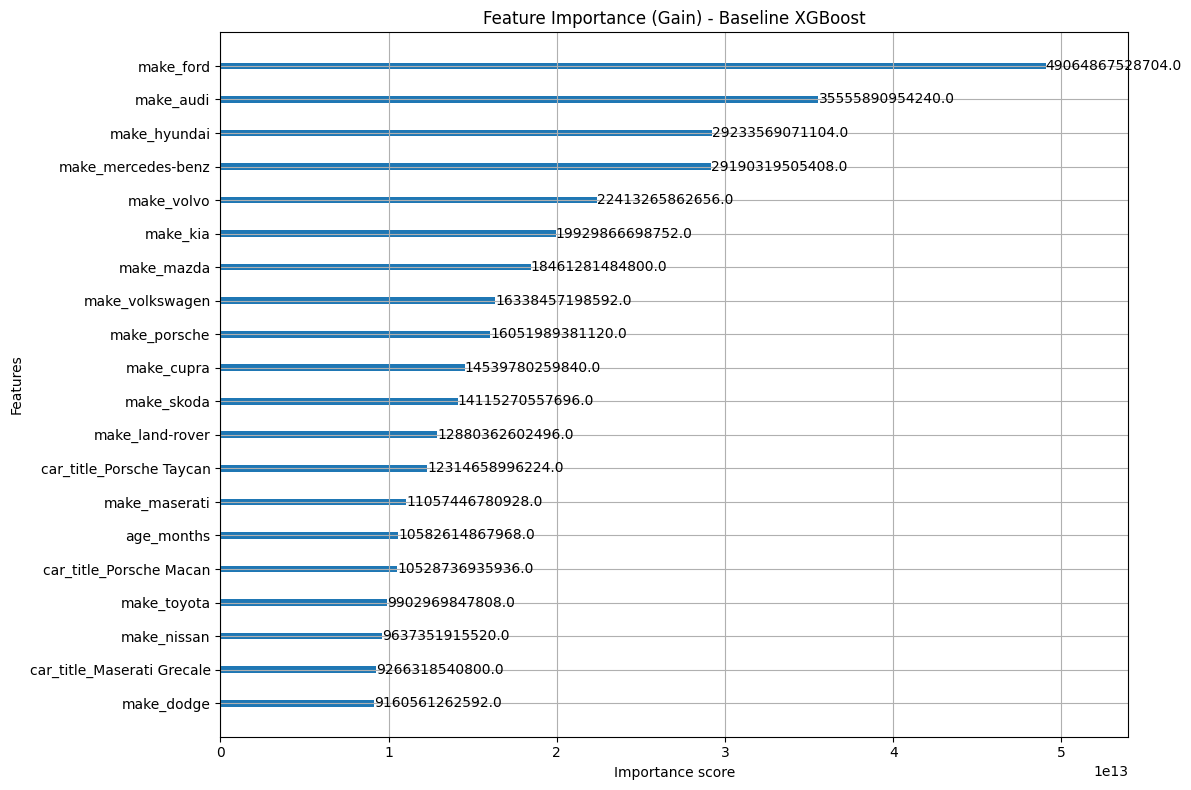

Top 10 features by gain: [('make_ford', 49064867528704.0), ('make_audi', 35555890954240.0), ('make_hyundai', 29233569071104.0), ('make_mercedes-benz', 29190319505408.0), ('make_volvo', 22413265862656.0), ('make_kia', 19929866698752.0), ('make_mazda', 18461281484800.0), ('make_volkswagen', 16338457198592.0), ('make_porsche', 16051989381120.0), ('make_cupra', 14539780259840.0)]


In [ ]:
# --- 10. Feature Importance (Optional but useful) ---
print("\n--- Feature Importance (Baseline Model) ---")
# Plot feature importance
fig, ax = plt.subplots(figsize=(12, 8)) # Adjust height based on num features
xgb.plot_importance(bst_model, ax=ax, max_num_features=20, importance_type='gain') # Show top 20 features by gain
plt.title("Feature Importance (Gain) - Baseline XGBoost")
plt.tight_layout()
plt.show()

# You can also get importance as a dictionary
# importance_types: 'weight', 'gain', 'cover', 'total_gain', 'total_cover'
# 'gain' is often a good default for feature contribution.
feature_importance_gain = bst_model.get_score(importance_type='gain')
print("Top 10 features by gain:", sorted(feature_importance_gain.items(), key=lambda item: item[1], reverse=True)[:10])

It seems like unsurprisingly the make and car_title were the most significant predictors by feature importance.

## Hyperparameter Tuning

In [ ]:
# Example using RandomizedSearchCV (conceptual)
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

xgb_reg = XGBRegressor(
    objective='reg:squarederror',
    seed=42,
    eval_metric='mae',
    early_stopping_rounds=10
)

param_dist = {
    'n_estimators': [100, 200, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5]
}

random_search = RandomizedSearchCV(
    xgb_reg,
    param_distributions=param_dist,
    n_iter=25,  # Number of parameter settings that are sampled
    # Use a score that can be maximized (hence negative MAE)
    scoring='neg_mean_absolute_error',
    cv=3,      # 3-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1  # Use all available cores
)
# Note: RandomizedSearchCV expects dense data or a compatible sparse format.
# X_train_final (if sparse) should work.
random_search.fit(X_train_final, y_train,
                  eval_set=[(X_test_final, y_test)],
                  verbose=False)
print("Best parameters found: ", random_search.best_params_)
print("Best MAE found: ", -random_search.best_score_)
best_xgb_model = random_search.best_estimator_

Fitting 3 folds for each of 25 candidates, totalling 75 fits


: 